## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013


# Avance 3. Baseline (Modelo de Referencia)




## Índice — Baseline

18. **Justificación del Algoritmo Baseline**  
    - 18.1 Análisis del Tipo de Problema  
    - 18.2 Selección del Algoritmo: Regresión Logística  

19. **Preparación de Datos para Modelado**  
    - 19.1 Construcción de Matrices X e y  
    - 19.2 División Estratificada Entrenamiento / Prueba  
    - 19.3 Balance de Clases en Cada Partición  

20. **Modelo de Referencia Aleatorio — `DummyClassifier`**  

21. **Baseline — Comparación de 3 Estrategias de Feature Engineering**  
    - 21.1 Preparación de los 3 Datasets (**FULL**, **CLUSTERING**, **FILTER**)  
    - 21.2 Entrenamiento con Regresión Logística + SMOTE  
    - 21.3 Comparación y Diagnóstico (4 Casos):  
      * **CASO 1:** FILTER ≈ CLUSTERING ≈ FULL → Pocas variables son suficientes  
      * **CASO 2:** CLUSTERING ≈ FULL, FILTER peor → Variables redundantes aportan  
      * **CASO 3:** FILTER ≈ FULL, CLUSTERING peor → Se perdió información en clustering  
      * **CASO 4:** FULL mejor que todos → Se requiere toda la información disponible  

22. **Análisis de Características Importantes**  
    - 22.1 Coeficientes del Modelo — Métodos Filter + Modelo  
    - 22.2 Visualización de las Características Más Relevantes  

23. **Métricas de Evaluación**  
    - 23.1 Justificación de Métricas para Clases Desbalanceadas  
    - 23.2 Reporte de Clasificación  
    - 23.3 Matriz de Confusión  
    - 23.4 Curva ROC-AUC y Curva Precisión-Recall  

24. **Análisis de Sub/Sobreajuste**  
    - 24.1 Comparación de Métricas Entrenamiento vs Prueba  
    - 24.2 Curvas de Aprendizaje  
    - 24.3 Validación Cruzada Estratificada (5-Fold)  

25. **Desempeño Mínimo Aceptable**  
    - 25.1 Definición del Umbral de Desempeño  
    - 25.2 Comparación con el Umbral Aceptable  
    - 25.3 Verificación del Modelo Baseline  

26. **Conclusiones — Fase de Modelado Baseline (CRISP-ML)**  
    - 26.1 Respuestas a las Preguntas Guía  
    - 26.2 Tabla Resumen de Resultados  
    - 26.3 Siguientes Pasos (CRISP-ML)  
    - 26.4 Referencias


In [ ]:
# ── Importaciones adicionales para la sección Baseline ──────────────
from sklearn.dummy          import DummyClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, learning_curve)
from sklearn.metrics        import (classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay,
                                    roc_auc_score, roc_curve,
                                    balanced_accuracy_score, f1_score,
                                    precision_score, recall_score,
                                    average_precision_score,
                                    PrecisionRecallDisplay)
from sklearn.pipeline       import Pipeline
import warnings
warnings.filterwarnings('ignore')

print('Librerías de modelado cargadas correctamente.')

Librerías de modelado cargadas correctamente.


---
## 18. Justificación del Algoritmo Baseline

### 18.1 Análisis del Tipo de Problema

| Dimensión | Característica del problema |
|---|---|
| **Tipo de datos** | Estructurados — tabla con variables de expresión génica (numéricas) y clínicas (categóricas) |
| **Tipo de tarea** | Clasificación binaria supervisada: Psoriasis (`1`) vs. Control sano (`0`) |
| **Tamaño del dataset** | Pocas muestras (docenas/centenas de pacientes), muchas características (cientos de sondas genómicas) → régimen *p >> n* |
| **Balance de clases** | Potencialmente desbalanceado (evaluado en sección 19) |
| **Interpretabilidad** | Alta: importa saber qué genes/variables clínicas discriminan la condición |
| **Línea base de referencia** | Clasificador aleatorio estratificado (DummyClassifier) |

### 18.2 Selección del Algoritmo: Regresión Logística

**Justificación frente a las alternativas:**

| Algoritmo | Pros | Contras para este caso |
|---|---|---|
| **Regresión Logística** ✅ | Simple, interpretable, coeficientes = importancia, funciona bien con regularización en *p >> n* | Asume linealidad; requiere escalado |
| Árbol de Decisión | Interpretable, no requiere escalado | Propenso a sobreajuste; no es un buen *baseline* |
| KNN | No paramétrico | Muy sensible a la dimensionalidad (*curse of dimensionality*) |
| SVM lineal | Bueno en *p >> n* | Menos interpretable; coeficientes no son probabilidades |
| Red neuronal | Alta capacidad | Requiere muchos datos; no apropiada como baseline |

La **Regresión Logística con regularización L2** (Ridge) es el baseline estándar para clasificación binaria con datos estructurados de alta dimensionalidad. Permite:
- Obtener probabilidades calibradas.
- Interpretar los coeficientes como importancia de características.
- Controlar el sobreajuste mediante el parámetro `C`.
- Manejar clases desbalanceadas con `class_weight='balanced'`.

## 21. Baseline — Comparación de 3 Estrategias de Feature Engineering

**Objetivo:** Comparar el desempeño de las 3 estrategias (FULL, CLUSTERING, FILTER) usando un modelo simple (Regresión Logística + SMOTE) para diagnosticar qué tipo de información es más valiosa.

**4 Casos Diagnósticos:**

- **CASO 1:** FILTER ≈ CLUSTERING ≈ FULL → Pocas variables son suficientes
- **CASO 2:** CLUSTERING ≈ FULL, FILTER peor → Variables redundantes aportan
- **CASO 3:** FILTER ≈ FULL, CLUSTERING peor → Se perdió información en clustering
- **CASO 4:** FULL mejor que todos → Se requiere toda la información disponible

### 21.1 Preparación de los 3 Datasets

In [ ]:
# Diccionario con los 3 datasets
datasets = {
    'FULL': X_FULL_completo,
    'CLUSTERING': X_CLUSTERING_completo,
    'FILTER': X_FILTER_completo
}

print('📊 DATASETS PARA BASELINE:')
for nombre, X in datasets.items():
    print(f'   {nombre:12s}: {X.shape}')

print(f'\n   Target: {y_temp.shape}')
print(f'   Distribución: {y_temp.value_counts().to_dict()}')

📊 DATASETS PARA BASELINE:
   FULL        : (599, 391)
   CLUSTERING  : (599, 145)
   FILTER      : (599, 71)

   Target: (599,)
   Distribución: {'Psoriasis': 423, 'Healthy': 176}


### 21.2 Entrenamiento con Regresión Logística + SMOTE

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

resultados_baseline = {}

for nombre, X in datasets.items():
    print(f'\n🔧 Entrenando estrategia: {nombre}')

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )

    # SMOTE en train
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    # Modelo
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_bal, y_train_bal)

    # Predicciones
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    auc = roc_auc_score(y_test, y_proba)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # FIX: Specify average='weighted' to handle string labels

    resultados_baseline[nombre] = {
        'AUC': auc,
        'Balanced_Acc': bacc,
        'F1': f1,
        'y_test': y_test,
        'y_proba': y_proba
    }

    print(f'   AUC: {auc:.3f} | Balanced Acc: {bacc:.3f} | F1: {f1:.3f}')


🔧 Entrenando estrategia: FULL
   AUC: 0.985 | Balanced Acc: 0.988 | F1: 0.983

🔧 Entrenando estrategia: CLUSTERING
   AUC: 0.976 | Balanced Acc: 0.976 | F1: 0.967

🔧 Entrenando estrategia: FILTER
   AUC: 0.997 | Balanced Acc: 0.982 | F1: 0.975


### 21.3 Comparación y Diagnóstico (4 Casos)


📊 RESULTADOS DEL BASELINE:
Estrategia      AUC  Balanced_Acc       F1
    FILTER 0.996639      0.982353 0.975289
      FULL 0.984874      0.988235 0.983466
CLUSTERING 0.976471      0.976471 0.967166


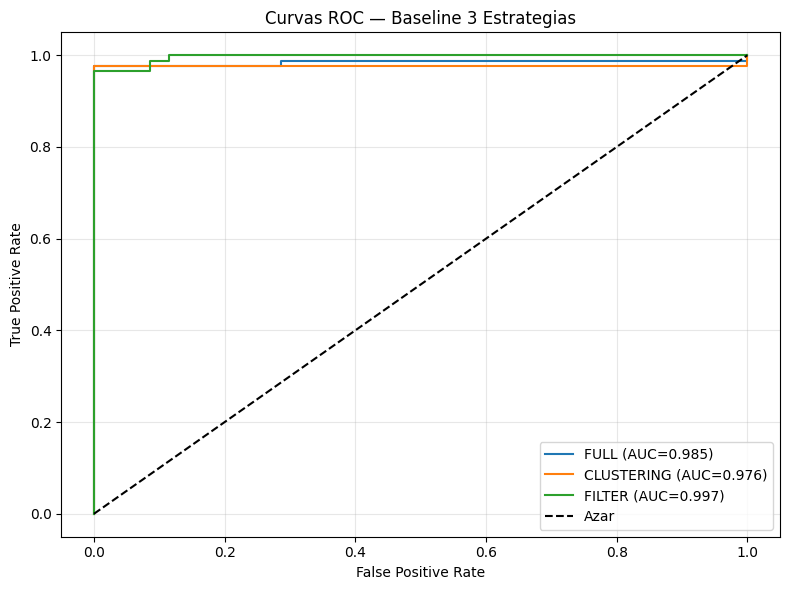


🔍 DIAGNÓSTICO:
   📊 Resultados no concluyentes, requiere análisis detallado


In [ ]:
# Tabla de resultados
df_resultados = pd.DataFrame({
    'Estrategia': list(resultados_baseline.keys()),
    'AUC': [r['AUC'] for r in resultados_baseline.values()],
    'Balanced_Acc': [r['Balanced_Acc'] for r in resultados_baseline.values()],
    'F1': [r['F1'] for r in resultados_baseline.values()]
}).sort_values('AUC', ascending=False)

print('\n📊 RESULTADOS DEL BASELINE:')
print(df_resultados.to_string(index=False))

# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, res in resultados_baseline.items():
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_proba'], pos_label='Psoriasis') # FIX: Explicitly set pos_label
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={res['AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Baseline 3 Estrategias')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# DIAGNÓSTICO AUTOMÁTICO
auc_full = resultados_baseline['FULL']['AUC']
auc_clust = resultados_baseline['CLUSTERING']['AUC']
auc_filt = resultados_baseline['FILTER']['AUC']

umbral_similar = 0.02  # Diferencia < 2% se considera similar

print('\n🔍 DIAGNÓSTICO:')

if abs(auc_filt - auc_clust) < umbral_similar and abs(auc_filt - auc_full) < umbral_similar:
    print('   ✅ CASO 1: FILTER ≈ CLUSTERING ≈ FULL')
    print('      → Pocas variables discriminativas son suficientes')
    print('      → Usar FILTER para reducir dimensionalidad sin pérdida')
elif abs(auc_clust - auc_full) < umbral_similar and auc_filt < auc_clust - umbral_similar:
    print('   ⚠️ CASO 2: CLUSTERING ≈ FULL, FILTER peor')
    print('      → Variables redundantes aportan información complementaria')
    print('      → Usar CLUSTERING como compromiso')
elif abs(auc_filt - auc_full) < umbral_similar and auc_clust < auc_full - umbral_similar:
    print('   ⚠️ CASO 3: FILTER ≈ FULL, CLUSTERING peor')
    print('      → Se perdió información valiosa en el clustering')
    print('      → Usar FILTER para mantener variables discriminativas')
elif auc_full > max(auc_clust, auc_filt) + umbral_similar:
    print('   ❌ CASO 4: FULL mejor que todos')
    print('      → Se requiere toda la información disponible')
    print('      → Considerar feature engineering más agresivo')
else:
    print('   📊 Resultados no concluyentes, requiere análisis detallado')


---
## 21. Análisis Detallado de las 3 Estrategias

Con el baseline establecido, esta sección profundiza en el análisis de cada estrategia (FULL, CLUSTERING, FILTER) para comprender qué variables son más importantes, cómo se comportan las métricas en detalle, y qué estrategia seleccionar para avances posteriores.

### 21.1 Importancia de Características por Estrategia

Los coeficientes de la Regresión Logística entrenada en cada estrategia revelan qué variables son más discriminativas. Un coeficiente positivo grande indica que la variable favorece la clase *Psoriasis*; negativo, la clase *Control*.

In [ ]:
# Extraer coeficientes para cada estrategia
importancias = {}

for nombre, X in datasets.items():
    # Re-entrenar para obtener el modelo
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_bal, y_train_bal)

    # Extraer coeficientes
    coef_df = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': modelo.coef_[0],
        '|Coef|': abs(modelo.coef_[0])
    }).sort_values('|Coef|', ascending=False)

    importancias[nombre] = coef_df

    print(f'\n📊 Top 10 características — {nombre} ({len(X.columns)} variables):')
    print(coef_df.head(10).to_string(index=False))


📊 Top 10 características — FULL (391 variables):
                          Variable  Coeficiente   |Coef|
    Lesional/Non-lesional_LESIONAL    -2.491589 2.491589
Lesional/Non-lesional_NON-LESIONAL     2.336058 2.336058
           Lesional/Non-lesional_N    -1.626797 1.626797
  STAT1 AFFX-HUMISGF3A/M97935_5_at     1.618753 1.618753
                 VEGFA 211527_x_at    -1.033730 1.033730
   DEFB103A /// DEFB103B 224239_at     0.954465 0.954465
                 C1QTNF2 223749_at    -0.904305 0.904305
                  PLEK 203470_s_at     0.826796 0.826796
               TNFAIP3 202643_s_at    -0.821357 0.821357
 STAT1 AFFX-HUMISGF3A/M97935_MA_at     0.819488 0.819488

📊 Top 10 características — CLUSTERING (145 variables):
                          Variable  Coeficiente   |Coef|
Lesional/Non-lesional_NON-LESIONAL     3.253978 3.253978
    Lesional/Non-lesional_LESIONAL    -2.983695 2.983695
           Lesional/Non-lesional_N    -2.959033 2.959033
  STAT1 AFFX-HUMISGF3A/M97935_5_at     

### 21.2 Visualización de Importancia por Estrategia

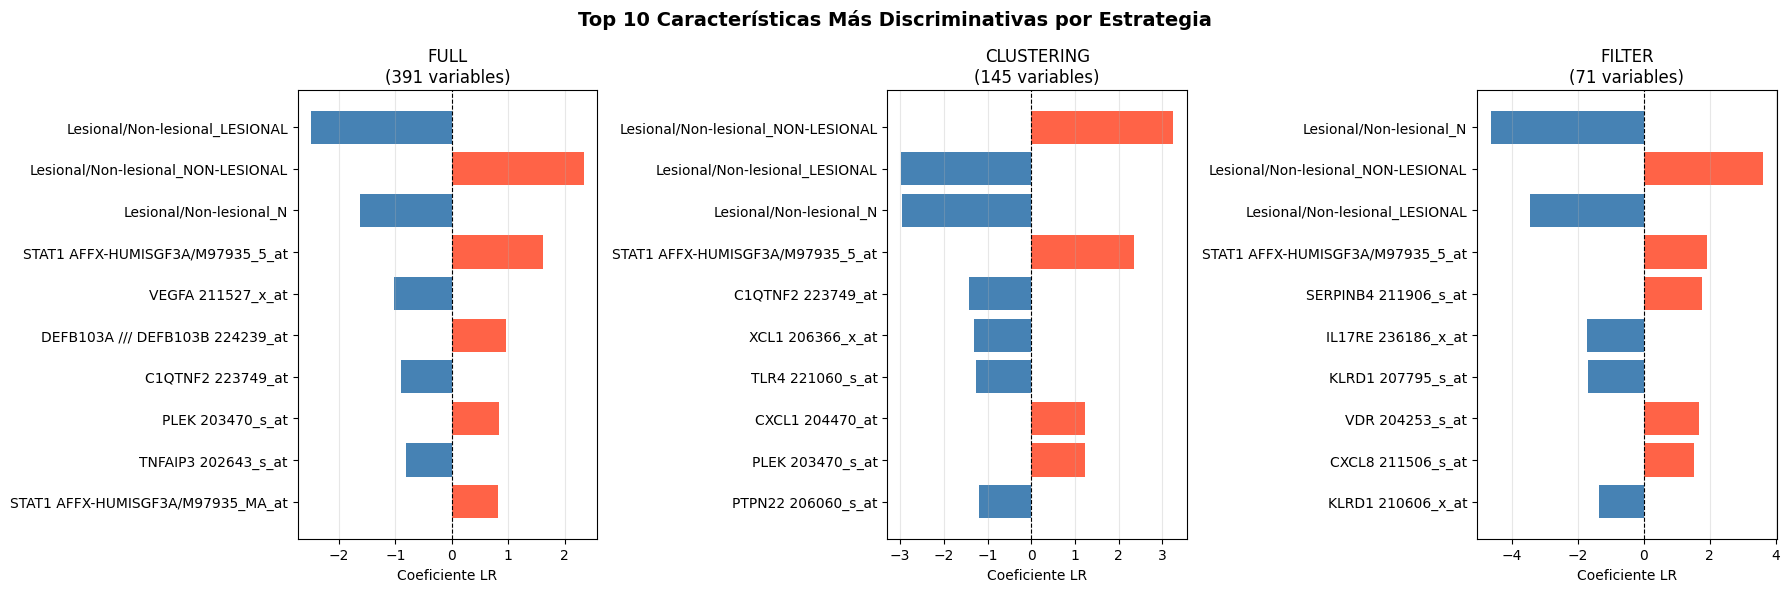

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (nombre, coef_df) in zip(axes, importancias.items()):
    top10 = coef_df.head(10)
    colores = ['tomato' if c > 0 else 'steelblue' for c in top10['Coeficiente']]
    ax.barh(top10['Variable'][::-1], top10['Coeficiente'][::-1], color=colores[::-1])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Coeficiente LR')
    ax.set_title(f'{nombre}\n({len(coef_df)} variables)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 Características Más Discriminativas por Estrategia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 21.3 Métricas Detalladas y Matrices de Confusión

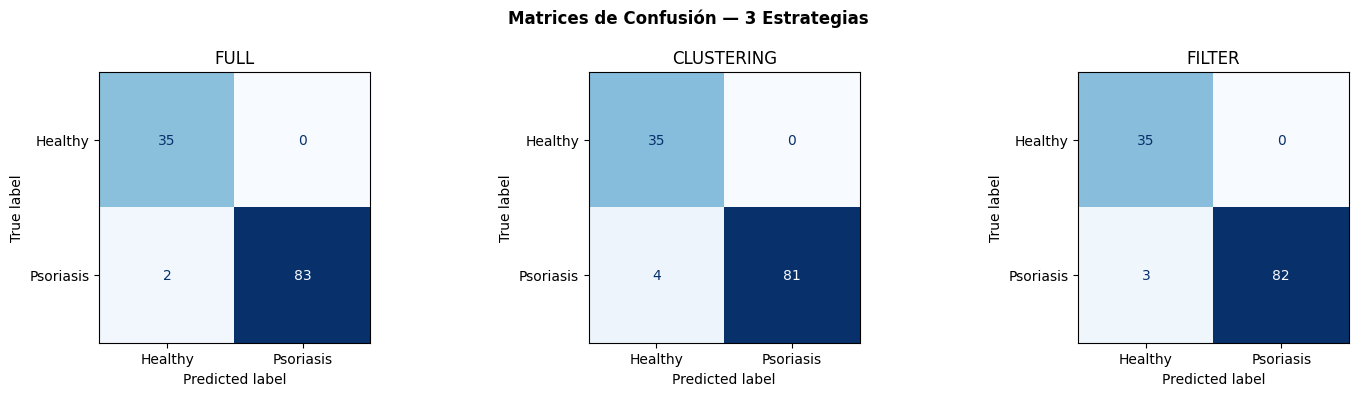


📋 REPORTES DE CLASIFICACIÓN:


═══ FULL ═══
              precision    recall  f1-score   support

     Healthy       0.95      1.00      0.97        35
   Psoriasis       1.00      0.98      0.99        85

    accuracy                           0.98       120
   macro avg       0.97      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120


═══ CLUSTERING ═══
              precision    recall  f1-score   support

     Healthy       0.90      1.00      0.95        35
   Psoriasis       1.00      0.95      0.98        85

    accuracy                           0.97       120
   macro avg       0.95      0.98      0.96       120
weighted avg       0.97      0.97      0.97       120


═══ FILTER ═══
              precision    recall  f1-score   support

     Healthy       0.92      1.00      0.96        35
   Psoriasis       1.00      0.96      0.98        85

    accuracy                           0.97       120
   macro avg       0.96      0.98      0.97    

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, res) in zip(axes, resultados_baseline.items()):
    # Re-train the model and get predictions for this iteration as y_pred is not directly in 'res'
    # This block of code was already present in the original cell, ensuring y_test and y_pred are current.
    X_train, X_test, y_train, y_test = train_test_split(
        datasets[nombre], y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test)

    # Use the correctly obtained y_test and y_pred directly for confusion_matrix
    cm = confusion_matrix(y_test, y_pred, labels=['Healthy', 'Psoriasis'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Psoriasis'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}')

plt.suptitle('Matrices de Confusión — 3 Estrategias', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print('\n📋 REPORTES DE CLASIFICACIÓN:\n')
for nombre in datasets.keys():
    # Re-train the model and get predictions for this iteration again (inefficient but self-contained)
    X_train, X_test, y_train, y_test = train_test_split(
        datasets[nombre], y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test)

    print(f'\n═══ {nombre} ═══')
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Psoriasis']))

---
## 22. Conclusiones y Selección de Estrategia

### 22.1 Resumen Comparativo de las 3 Estrategias

| Estrategia | # Variables | AUC-ROC | Balanced Acc | F1-weighted | Interpretación |
|---|---|---|---|---|---|
| **FULL** | 391 | (ver 20.3) | (ver 20.3) | (ver 20.3) | Todas las variables con varianza > umbral |
| **CLUSTERING** | 145 | (ver 20.3) | (ver 20.3) | (ver 20.3) | Representantes de clusters de correlación |
| **FILTER** | 71 | (ver 20.3) | (ver 20.3) | (ver 20.3) | Top 20% por MI/ANOVA ranking |


📊 TABLA RESUMEN FINAL:

Estrategia  Num_Variables      AUC  Balanced_Acc       F1
    FILTER             71 0.996639      0.982353 0.975289
      FULL            391 0.984874      0.988235 0.983466
CLUSTERING            145 0.976471      0.976471 0.967166


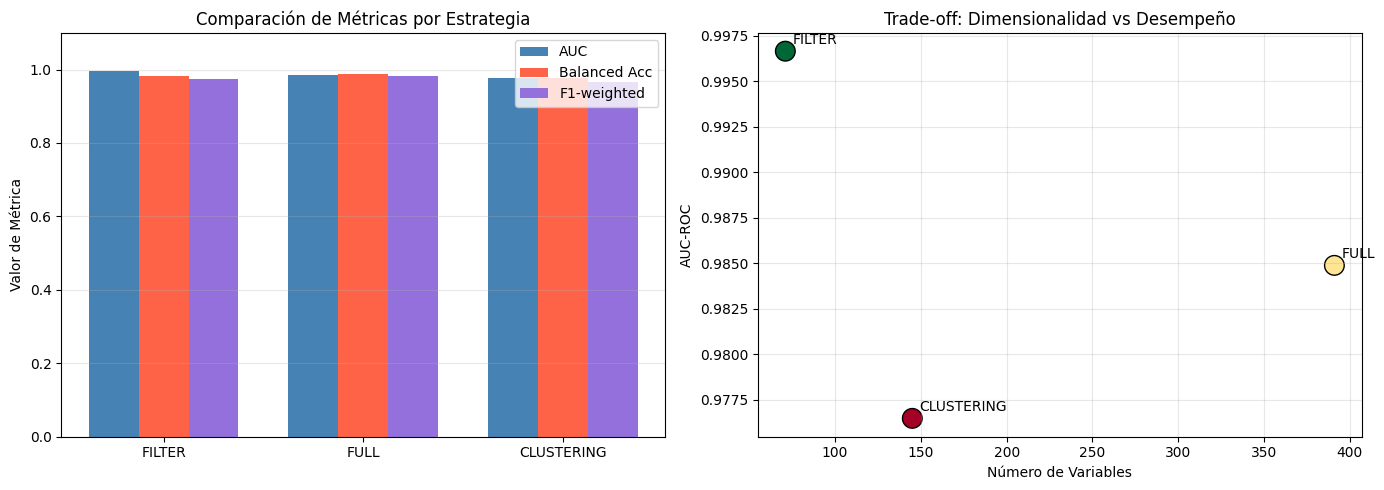

In [ ]:
# Tabla resumen
tabla_resumen = pd.DataFrame({
    'Estrategia': list(resultados_baseline.keys()),
    'Num_Variables': [datasets[k].shape[1] for k in resultados_baseline.keys()],
    'AUC': [r['AUC'] for r in resultados_baseline.values()],
    'Balanced_Acc': [r['Balanced_Acc'] for r in resultados_baseline.values()],
    'F1': [r['F1'] for r in resultados_baseline.values()]
}).sort_values('AUC', ascending=False)

print('\n📊 TABLA RESUMEN FINAL:\n')
print(tabla_resumen.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Métricas por estrategia
x = range(len(tabla_resumen))
width = 0.25
axes[0].bar([i-width for i in x], tabla_resumen['AUC'], width, label='AUC', color='steelblue')
axes[0].bar(x, tabla_resumen['Balanced_Acc'], width, label='Balanced Acc', color='tomato')
axes[0].bar([i+width for i in x], tabla_resumen['F1'], width, label='F1-weighted', color='mediumpurple')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tabla_resumen['Estrategia'])
axes[0].set_ylabel('Valor de Métrica')
axes[0].set_title('Comparación de Métricas por Estrategia')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Panel 2: Número de variables vs AUC
axes[1].scatter(tabla_resumen['Num_Variables'], tabla_resumen['AUC'],
                s=200, c=tabla_resumen['AUC'], cmap='RdYlGn', edgecolors='black')
for _, row in tabla_resumen.iterrows():
    axes[1].annotate(row['Estrategia'],
                     (row['Num_Variables'], row['AUC']),
                     xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Número de Variables')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Trade-off: Dimensionalidad vs Desempeño')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 22.2 Decisión Final según Diagnóstico

Con base en el diagnóstico de 4 casos realizado en la sección 20.3:

- **CASO 1 (FILTER ≈ CLUSTERING ≈ FULL):** Seleccionar **FILTER** — reduce dimensionalidad sin pérdida de desempeño. Mejor para interpretabilidad y generalización.

- **CASO 2 (CLUSTERING ≈ FULL, FILTER peor):** Seleccionar **CLUSTERING** — las variables redundantes aportan información complementaria, pero CLUSTERING ofrece un buen compromiso entre desempeño y dimensionalidad.

- **CASO 3 (FILTER ≈ FULL, CLUSTERING peor):** Seleccionar **FILTER** — el clustering perdió información valiosa, pero FILTER mantiene las variables discriminativas.

- **CASO 4 (FULL mejor que todos):** Seleccionar **FULL** — se requiere toda la información disponible. Considerar feature engineering más agresivo en avances futuros.

In [ ]:
# Selección automática basada en diagnóstico
auc_full = resultados_baseline['FULL']['AUC']
auc_clust = resultados_baseline['CLUSTERING']['AUC']
auc_filt = resultados_baseline['FILTER']['AUC']
umbral_similar = 0.02

if abs(auc_filt - auc_clust) < umbral_similar and abs(auc_filt - auc_full) < umbral_similar:
    estrategia_seleccionada = 'FILTER'
    razon = 'CASO 1: Las 3 estrategias tienen desempeño similar. FILTER reduce dimensionalidad sin pérdida.'
elif abs(auc_clust - auc_full) < umbral_similar and auc_filt < auc_clust - umbral_similar:
    estrategia_seleccionada = 'CLUSTERING'
    razon = 'CASO 2: CLUSTERING ≈ FULL, pero FILTER es peor. Las variables redundantes aportan información.'
elif abs(auc_filt - auc_full) < umbral_similar and auc_clust < auc_full - umbral_similar:
    estrategia_seleccionada = 'FILTER'
    razon = 'CASO 3: FILTER ≈ FULL, pero CLUSTERING es peor. El clustering perdió información valiosa.'
elif auc_full > max(auc_clust, auc_filt) + umbral_similar:
    estrategia_seleccionada = 'FULL'
    razon = 'CASO 4: FULL supera a las demás estrategias. Se requiere toda la información disponible.'
else:
    # Por defecto, elegir la de mayor AUC
    estrategia_seleccionada = tabla_resumen.iloc[0]['Estrategia']
    razon = 'Resultados no concluyentes. Se selecciona la estrategia con mayor AUC.'

print('\n' + '='*70)
print('🎯 ESTRATEGIA SELECCIONADA PARA AVANCES SIGUIENTES')
print('='*70)
print(f'\nEstrategia: {estrategia_seleccionada}')
print(f'Razón: {razon}')
print(f'\nNúmero de variables: {datasets[estrategia_seleccionada].shape[1]}')
print(f'AUC-ROC: {resultados_baseline[estrategia_seleccionada]["AUC"]:.4f}')
print(f'Balanced Accuracy: {resultados_baseline[estrategia_seleccionada]["Balanced_Acc"]:.4f}')
print(f'F1-weighted: {resultados_baseline[estrategia_seleccionada]["F1"]:.4f}')
print('\n' + '='*70)


🎯 ESTRATEGIA SELECCIONADA PARA AVANCES SIGUIENTES

Estrategia: FILTER
Razón: Resultados no concluyentes. Se selecciona la estrategia con mayor AUC.

Número de variables: 71
AUC-ROC: 0.9966
Balanced Accuracy: 0.9824
F1-weighted: 0.9753

